# Stage 2 — Demand Forecasting

## Objective

Build and evaluate 13-week weekly demand forecasts for the 20-SKU
regional M5 panel created during Stage 1.

The forecasting benchmark compares three levels of model complexity:

### Simple baselines

- Naive
- Seasonal naive (52 weeks)
- Drift
- 4-week moving average
- 13-week moving average

### Classical statistical forecasting

- ETS / Holt-Winters
- Theta
- ARIMA
- SARIMA

### Machine learning

- Global LightGBM

Models are evaluated using expanding-window rolling-origin validation.
The initial experiment uses three 13-week validation folds followed by
a final 13-week holdout.

Metrics:

- MAE
- RMSE
- WAPE
- sMAPE
- Forecast bias

In [5]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PROJECT PATHS
# ============================================================

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate project root."
    )


PROJECT_ROOT = find_project_root()

FORECAST_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "forecasting"
)

PANEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "m5_weekly_panel.parquet"
)


# ============================================================
# LOAD RESULTS
# ============================================================

panel = pd.read_parquet(PANEL_PATH)

cv_metrics = pd.read_csv(
    FORECAST_DIR / "cv_metrics.csv"
)

cv_summary = pd.read_csv(
    FORECAST_DIR / "cv_summary.csv"
)

test_metrics = pd.read_csv(
    FORECAST_DIR / "test_metrics.csv"
)

test_predictions = pd.read_parquet(
    FORECAST_DIR / "test_predictions.parquet"
)

test_metrics_by_sku = pd.read_csv(
    FORECAST_DIR / "test_metrics_by_sku.csv"
)


print("Panel:", panel.shape)
print("CV metrics:", cv_metrics.shape)
print("Test predictions:", test_predictions.shape)

print("\nModels:")
print(
    sorted(
        test_metrics["model"].unique()
    )
)

Panel: (5540, 25)
CV metrics: (30, 9)
Test predictions: (2600, 6)

Models:
['arima_aic', 'drift', 'ets_additive_52', 'lightgbm', 'moving_average_13', 'moving_average_4', 'naive', 'sarima_52', 'seasonal_naive_52', 'theta_52']


In [36]:
# ============================================================
# NOTEBOOK DEVELOPMENT MODE
# ============================================================
#
# Automatically reload project modules when their .py files change.
# This prevents the notebook from continuing to use stale function
# definitions while we iterate on forecasting code.

%load_ext autoreload
%autoreload 2

In [38]:
import new_demfor_planopti.forecasting.features as ff

## 1. Rolling-origin validation

Model selection must occur on historical validation periods rather than
the final holdout.

A single validation window can produce misleading conclusions if demand
behaviour changes over time. We therefore inspect each rolling-origin
fold individually before interpreting the average score.

In [39]:
cv_table = (
    cv_metrics
    .pivot(
        index="model",
        columns="split",
        values="wape",
    )
)

validation_columns = [
    col
    for col in cv_table.columns
    if col.startswith("validation_")
]

cv_table["mean_wape"] = (
    cv_table[validation_columns]
    .mean(axis=1)
)

cv_table["std_wape"] = (
    cv_table[validation_columns]
    .std(axis=1)
)

cv_table = (
    cv_table
    .sort_values("mean_wape")
)

cv_table.round(2)

split,validation_1,validation_2,validation_3,mean_wape,std_wape
model,,,,,
seasonal_naive_52,37.01,2.316000e+01,2.793000e+01,2.937000e+01,7.040000e+00
theta_52,40.45,2.662000e+01,3.006000e+01,3.238000e+01,7.200000e+00
ets_additive_52,34.94,3.318000e+01,3.484000e+01,3.432000e+01,9.900000e-01
lightgbm,41.75,3.338000e+01,3.208000e+01,3.574000e+01,5.250000e+00
moving_average_13,41.68,3.001000e+01,4.157000e+01,3.775000e+01,6.710000e+00
arima_aic,45.72,3.565000e+01,3.750000e+01,3.962000e+01,5.360000e+00
moving_average_4,47.34,3.574000e+01,3.701000e+01,4.003000e+01,6.360000e+00
naive,53.31,4.459000e+01,3.681000e+01,4.490000e+01,8.250000e+00
drift,53.47,4.638000e+01,3.680000e+01,4.555000e+01,8.370000e+00


## 2. Validation stability versus final holdout

The model selected by rolling validation does not necessarily rank first
on every future period.

A substantial ranking change between validation and holdout can indicate
temporal regime change, changing demand level, or unstable model behaviour.

In [40]:
comparison = (
    cv_summary[
        [
            "model",
            "mean_wape",
            "std_wape",
        ]
    ]
    .merge(
        test_metrics[
            [
                "model",
                "wape",
                "bias_pct",
            ]
        ],
        on="model",
        how="left",
        validate="one_to_one",
    )
    .rename(
        columns={
            "wape": "test_wape",
            "bias_pct": "test_bias_pct",
        }
    )
)

comparison["test_minus_cv_wape"] = (
    comparison["test_wape"]
    - comparison["mean_wape"]
)

comparison.sort_values(
    "test_wape"
).round(2)

,model,mean_wape,std_wape,test_wape,test_bias_pct,test_minus_cv_wape
8,drift,4.555000e+01,8.370000e+00,20.74,9.75,-2.481000e+01
7,naive,4.490000e+01,8.250000e+00,20.94,10.30,-2.397000e+01
6,moving_average_4,4.003000e+01,6.360000e+00,21.36,6.40,-1.867000e+01
5,arima_aic,3.962000e+01,5.360000e+00,21.95,3.56,-1.768000e+01
1,theta_52,3.238000e+01,7.200000e+00,26.47,16.23,-5.910000e+00
4,moving_average_13,3.775000e+01,6.710000e+00,28.73,-7.07,-9.020000e+00
3,lightgbm,3.574000e+01,5.250000e+00,29.77,-8.13,-5.960000e+00
0,seasonal_naive_52,2.937000e+01,7.040000e+00,30.04,-9.19,6.700000e-01
2,ets_additive_52,3.432000e+01,9.900000e-01,31.78,21.19,-2.540000e+00
9,sarima_52,5.954466e+13,1.031341e+14,98.13,-93.22,-5.954466e+13


### Interpretation of validation vs test performance

The final holdout produced a substantial change in the relative performance
of the forecasting models.

Seasonal naive remained close to its historical rolling-validation
performance:

- Mean CV WAPE: 29.37%
- Test WAPE: 30.04%

Therefore seasonal naive did not materially deteriorate during the final
period.

Instead, models driven primarily by recent demand level improved sharply:

- Drift: 45.55% mean CV WAPE -> 20.74% test WAPE
- Naive: 44.90% -> 20.94%
- 4-week moving average: 40.03% -> 21.36%
- ARIMA: 39.62% -> 21.95%

The fold-level trajectory also shows that naive and drift improved toward
the end of the dataset even before the final holdout.

This suggests that the later demand regime became increasingly dependent
on recent demand level/trend rather than same-period-last-year demand.

ETS was much more stable across historical validation folds but consistently
less accurate than the best seasonal benchmark.

The initial global LightGBM also improved across later forecast origins but
did not outperform recent-level statistical/simple models.

SARIMA produced numerically unstable forecasts and is therefore treated as
an invalid benchmark in its current specification rather than a meaningful
performance result.

## 3. Model performance across forecast origins

The rolling-validation folds are chronological forecast origins.

Plotting WAPE across these origins helps distinguish models that are
consistently strong from models whose usefulness changes as the demand
process evolves.

In [41]:
# ============================================================
# MODEL PERFORMANCE ACROSS FORECAST ORIGINS
# ============================================================

trajectory = cv_table[
    [
        "validation_1",
        "validation_2",
        "validation_3",
    ]
].copy()

trajectory["test"] = (
    test_metrics
    .set_index("model")
    ["wape"]
)

# SARIMA is excluded because its current specification is unstable.
trajectory = trajectory.drop(
    index="sarima_52",
    errors="ignore",
)

trajectory.round(2)

split,validation_1,validation_2,validation_3,test
model,,,,
seasonal_naive_52,37.01,23.16,27.93,30.04
theta_52,40.45,26.62,30.06,26.47
ets_additive_52,34.94,33.18,34.84,31.78
lightgbm,41.75,33.38,32.08,29.77
moving_average_13,41.68,30.01,41.57,28.73
arima_aic,45.72,35.65,37.50,21.95
moving_average_4,47.34,35.74,37.01,21.36
naive,53.31,44.59,36.81,20.94
drift,53.47,46.38,36.80,20.74


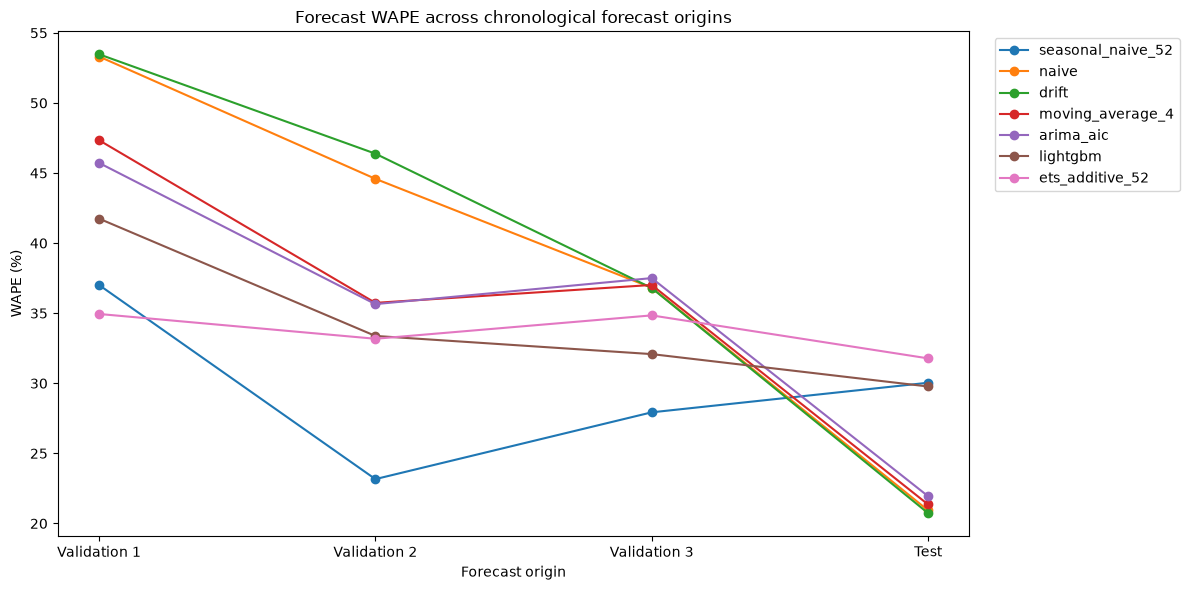

In [42]:
models_to_plot = [
    "seasonal_naive_52",
    "naive",
    "drift",
    "moving_average_4",
    "arima_aic",
    "lightgbm",
    "ets_additive_52",
]

periods = [
    "Validation 1",
    "Validation 2",
    "Validation 3",
    "Test",
]

plt.figure(
    figsize=(12, 6)
)

for model in models_to_plot:

    if model not in trajectory.index:
        continue

    values = trajectory.loc[
        model
    ].values

    plt.plot(
        periods,
        values,
        marker="o",
        label=model,
    )

plt.title(
    "Forecast WAPE across chronological forecast origins"
)

plt.xlabel(
    "Forecast origin"
)

plt.ylabel(
    "WAPE (%)"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [43]:
validation_predictions = pd.read_parquet(
    FORECAST_DIR
    / "validation_predictions.parquet"
)

validation_predictions[
    "week_start"
] = pd.to_datetime(
    validation_predictions[
        "week_start"
    ]
)

In [44]:
validation_periods = (
    validation_predictions
    .groupby(
        "split",
        as_index=False,
    )
    .agg(
        start_week=(
            "week_start",
            "min",
        ),
        end_week=(
            "week_start",
            "max",
        ),
        weeks=(
            "week_start",
            "nunique",
        ),
    )
)

test_period = pd.DataFrame(
    {
        "split": ["test"],
        "start_week": [
            pd.to_datetime(
                test_predictions[
                    "week_start"
                ]
            ).min()
        ],
        "end_week": [
            pd.to_datetime(
                test_predictions[
                    "week_start"
                ]
            ).max()
        ],
        "weeks": [
            test_predictions[
                "week_start"
            ].nunique()
        ],
    }
)

period_summary = pd.concat(
    [
        validation_periods,
        test_period,
    ],
    ignore_index=True,
)

period_summary

,split,start_week,end_week,weeks
0,validation_1,2015-05-23,2015-08-15,13
1,validation_2,2015-08-22,2015-11-14,13
2,validation_3,2015-11-21,2016-02-13,13
3,test,2016-02-20,2016-05-14,13


## 4. Investigating demand regime change

The changing model rankings suggest that recent demand level may have become
more informative toward the end of the dataset.

To investigate this, aggregate the 20 SKUs into total weekly portfolio demand
and compare short-run and annual demand levels.

In [46]:
panel[
    "week_start"
] = pd.to_datetime(
    panel[
        "week_start"
    ]
)

portfolio = (
    panel
    .groupby(
        "week_start",
        as_index=False,
    )
    .agg(
        demand=(
            "demand",
            "sum",
        )
    )
    .sort_values(
        "week_start"
    )
)

portfolio[
    "ma_13"
] = (
    portfolio[
        "demand"
    ]
    .rolling(13)
    .mean()
)

portfolio[
    "ma_52"
] = (
    portfolio[
        "demand"
    ]
    .rolling(52)
    .mean()
)

portfolio[
    "yoy_change_pct"
] = (
    portfolio[
        "demand"
    ]
    .pct_change(52)
    * 100
)

portfolio.tail(30)

,week_start,demand,ma_13,ma_52,yoy_change_pct
247,2015-10-24,10153,12394.461538,10637.673077,-1.254620
248,2015-10-31,9601,12125.538462,10620.403846,-8.553196
249,2015-11-07,8976,11828.384615,10606.153846,-7.625810
250,2015-11-14,8271,11366.769231,10594.692308,-6.721552
251,2015-11-21,11317,11292.846154,10571.538462,-9.615845
252,2015-11-28,7268,10916.538462,10536.173077,-20.193258
253,2015-12-05,7010,10375.923077,10507.903846,-17.334906
254,2015-12-12,6781,9909.461538,10481.403846,-16.889325
255,2015-12-19,6954,9357.769231,10466.288462,-10.155039
256,2015-12-26,7231,8999.461538,10457.788462,-5.760459


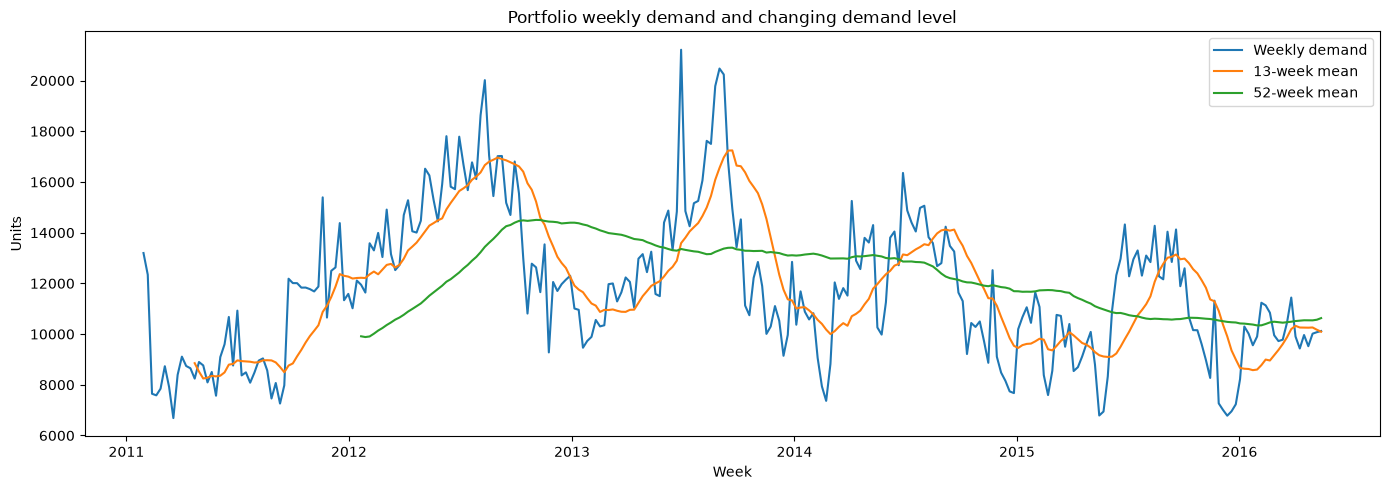

In [47]:
plt.figure(
    figsize=(14, 5)
)

plt.plot(
    portfolio[
        "week_start"
    ],
    portfolio[
        "demand"
    ],
    label="Weekly demand",
)

plt.plot(
    portfolio[
        "week_start"
    ],
    portfolio[
        "ma_13"
    ],
    label="13-week mean",
)

plt.plot(
    portfolio[
        "week_start"
    ],
    portfolio[
        "ma_52"
    ],
    label="52-week mean",
)

plt.title(
    "Portfolio weekly demand and changing demand level"
)

plt.xlabel(
    "Week"
)

plt.ylabel(
    "Units"
)

plt.legend()

plt.tight_layout()
plt.show()

In [48]:
portfolio[
    "recent_to_annual_level"
] = (
    portfolio[
        "ma_13"
    ]
    /
    portfolio[
        "ma_52"
    ]
)

portfolio[
    [
        "week_start",
        "demand",
        "ma_13",
        "ma_52",
        "recent_to_annual_level",
        "yoy_change_pct",
    ]
].tail(30).round(3)

C:\Users\krish\AppData\Local\Temp\ipykernel_31404\2900440640.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].tail(30).round(3)


,week_start,demand,ma_13,ma_52,recent_to_annual_level,yoy_change_pct
247,2015-10-24,10153,12394.462,10637.673,1.165,-1.255
248,2015-10-31,9601,12125.538,10620.404,1.142,-8.553
249,2015-11-07,8976,11828.385,10606.154,1.115,-7.626
250,2015-11-14,8271,11366.769,10594.692,1.073,-6.722
251,2015-11-21,11317,11292.846,10571.538,1.068,-9.616
252,2015-11-28,7268,10916.538,10536.173,1.036,-20.193
253,2015-12-05,7010,10375.923,10507.904,0.987,-17.335
254,2015-12-12,6781,9909.462,10481.404,0.945,-16.889
255,2015-12-19,6954,9357.769,10466.288,0.894,-10.155
256,2015-12-26,7231,8999.462,10457.788,0.861,-5.760


### Demand-regime interpretation

The model-ranking changes correspond to a clear change in the underlying
portfolio demand level.

During mid-2015, weekly demand remained relatively elevated and volatile.
Toward the end of 2015, demand declined sharply and the 13-week moving
average crossed below the 52-week moving average.

The ratio of recent (13-week) to annual (52-week) demand level declined
from approximately 1.17 in October 2015 to approximately 0.83 in January
2016.

By the final holdout period, demand had entered a lower and comparatively
more stable regime and gradually recovered toward its annual level.

This helps explain the changing model rankings:

- annual seasonal naive remained historically competitive but could not
  fully adapt to the changed demand level;
- naive, drift, short moving-average and ARIMA forecasts improved sharply
  as recent demand became more informative;
- the initial recursive LightGBM improved at later forecast origins but
  did not adapt sufficiently to outperform recent-level approaches.

This motivates explicit level-change and trend features in the next ML
iteration.

## 5. Model performance by SKU

Portfolio-level WAPE weights errors by total demand and can hide
heterogeneity across individual products.

The next analysis determines whether one model family dominates across
most SKUs or whether different products favour different forecasting
strategies.

In [49]:
# ============================================================
# BEST MODEL PER SKU
# ============================================================

best_model_by_sku = (
    test_metrics_by_sku
    .sort_values(
        [
            "sku_id",
            "wape",
        ]
    )
    .groupby(
        "sku_id",
        as_index=False,
    )
    .first()
)

best_model_by_sku[
    [
        "sku_id",
        "model",
        "wape",
        "bias_pct",
    ]
].round(2)

,sku_id,model,wape,bias_pct
0,FOODS_2_197,lightgbm,7.87,-6.72
1,FOODS_3_080,naive,3.45,-1.41
2,FOODS_3_090,naive,8.61,-6.44
3,FOODS_3_120,naive,28.81,28.10
4,FOODS_3_202,drift,8.77,-3.96
5,FOODS_3_252,lightgbm,7.52,-3.75
6,FOODS_3_281,arima_aic,9.95,-4.03
7,FOODS_3_318,drift,10.69,5.79
8,FOODS_3_319,seasonal_naive_52,34.96,30.47
9,FOODS_3_541,lightgbm,122.75,122.75


In [50]:
# ============================================================
# NUMBER OF SKU WINS PER MODEL
# ============================================================

sku_winner_counts = (
    best_model_by_sku[
        "model"
    ]
    .value_counts()
    .rename_axis("model")
    .reset_index(name="sku_wins")
)

sku_winner_counts

,model,sku_wins
0,lightgbm,5
1,arima_aic,4
2,seasonal_naive_52,4
3,naive,3
4,drift,2
5,moving_average_4,2


In [51]:
# ============================================================
# MEDIAN SKU-LEVEL WAPE BY MODEL
# ============================================================

sku_model_summary = (
    test_metrics_by_sku
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        mean_sku_wape=(
            "wape",
            "mean",
        ),
        median_sku_wape=(
            "wape",
            "median",
        ),
        worst_sku_wape=(
            "wape",
            "max",
        ),
        mean_abs_bias=(
            "bias_pct",
            lambda x:
                x.abs().mean(),
        ),
    )
    .sort_values(
        "median_sku_wape"
    )
)

sku_model_summary.round(2)

,model,mean_sku_wape,median_sku_wape,worst_sku_wape,mean_abs_bias
9,theta_52,55.45,10.28,314.10,53.55
0,arima_aic,41.19,11.90,204.36,38.43
1,drift,41.68,11.93,205.39,39.10
6,naive,42.04,12.32,206.49,39.56
5,moving_average_4,41.19,12.38,207.16,38.80
4,moving_average_13,44.51,16.33,169.85,35.13
2,ets_additive_52,61.01,20.91,323.87,57.42
3,lightgbm,36.44,24.93,122.75,32.46
8,seasonal_naive_52,38.58,35.01,139.44,32.34
7,sarima_52,102.36,97.04,144.00,86.75


## 6. LightGBM error by forecast horizon

The initial global LightGBM generates multi-step forecasts recursively.

A prediction for week +1 becomes part of the lag history used to forecast
week +2, and this process continues through week +13.

If forecast errors increase systematically with horizon, recursive error
propagation is likely limiting model performance.

In [52]:
# ============================================================
# ISOLATE LIGHTGBM TEST FORECASTS
# ============================================================

lightgbm_test = (
    test_predictions.loc[
        test_predictions[
            "model"
        ].eq(
            "lightgbm"
        )
    ]
    .copy()
)

lightgbm_test[
    "week_start"
] = pd.to_datetime(
    lightgbm_test[
        "week_start"
    ]
)


# ============================================================
# ASSIGN FORECAST HORIZON
# ============================================================

forecast_weeks = (
    lightgbm_test[
        "week_start"
    ]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

horizon_lookup = {
    week: horizon
    for horizon, week in enumerate(
        forecast_weeks,
        start=1,
    )
}

lightgbm_test[
    "horizon"
] = (
    lightgbm_test[
        "week_start"
    ]
    .map(
        horizon_lookup
    )
)


# ============================================================
# ERROR
# ============================================================

lightgbm_test[
    "abs_error"
] = (
    lightgbm_test[
        "actual"
    ]
    - lightgbm_test[
        "prediction"
    ]
).abs()


horizon_error = (
    lightgbm_test
    .groupby(
        "horizon",
        as_index=False,
    )
    .agg(
        mae=(
            "abs_error",
            "mean",
        ),
        total_actual=(
            "actual",
            "sum",
        ),
        total_abs_error=(
            "abs_error",
            "sum",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
    )
)


horizon_error[
    "wape"
] = (
    100
    * horizon_error[
        "total_abs_error"
    ]
    / horizon_error[
        "total_actual"
    ]
)


horizon_error.round(2)

,horizon,mae,total_actual,total_abs_error,mean_prediction,mean_actual,wape
0,1,64.80,10842,1295.95,507.84,542.10,11.95
1,2,140.46,9953,2809.28,492.30,497.65,28.23
2,3,188.10,9724,3761.91,506.40,486.20,38.69
3,4,140.65,9779,2812.96,475.33,488.95,28.77
4,5,140.47,10448,2809.30,455.46,522.40,26.89
5,6,204.01,11440,4080.20,447.39,572.00,35.67
6,7,204.42,9903,4088.41,458.80,495.15,41.28
7,8,168.13,9432,3362.63,437.85,471.60,35.65
8,9,167.12,9963,3342.43,428.35,498.15,33.55
9,10,125.97,9522,2519.30,430.56,476.10,26.46


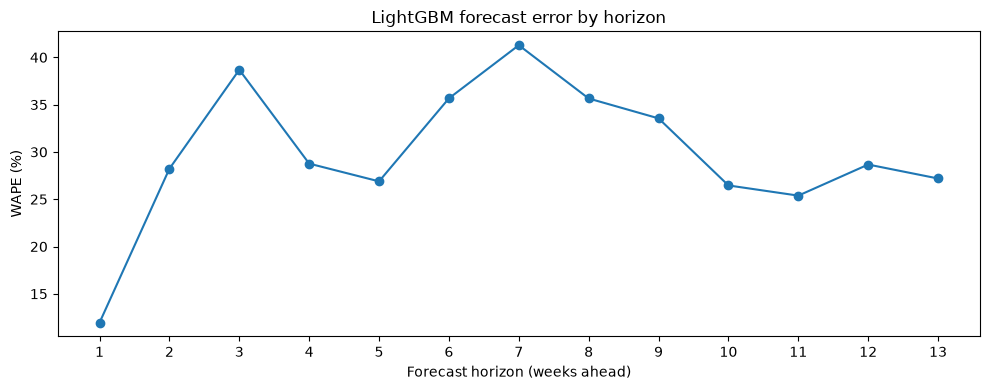

In [53]:
plt.figure(
    figsize=(10, 4)
)

plt.plot(
    horizon_error[
        "horizon"
    ],
    horizon_error[
        "wape"
    ],
    marker="o",
)

plt.title(
    "LightGBM forecast error by horizon"
)

plt.xlabel(
    "Forecast horizon (weeks ahead)"
)

plt.ylabel(
    "WAPE (%)"
)

plt.xticks(
    range(
        1,
        14,
    )
)

plt.tight_layout()
plt.show()

## 8. Iteration 2 — Regime-aware demand features

The initial model diagnostics showed that recent demand level became
increasingly important toward the end of the data.

The first ML improvement therefore adds explicit short-run versus
long-run demand-level and trend features.

No model architecture has been changed yet.

In [54]:
import inspect
import new_demfor_planopti.forecasting.features as ff

print("Module path:")
print(ff.__file__)

print("\nTrend features:")
print(ff.TREND_FEATURES)

print("\nDoes function source contain new feature code?")
source = inspect.getsource(ff.add_forecasting_features)

print(
    "level_diff_4_13" in source
)

print(
    "level_ratio_13_52" in source
)

Module path:
T:\Tanmay@IITK\Projects\new_demfor_planopti\src\new_demfor_planopti\forecasting\features.py

Trend features:
['level_diff_4_13', 'level_diff_13_52', 'level_ratio_4_13', 'level_ratio_13_52', 'recent_change_4', 'recent_change_13', 'yoy_delta']

Does function source contain new feature code?
True
True


In [55]:
print(
    "First return position:",
    source.find("return df"),
)

print(
    "New feature block position:",
    source.find('df["level_diff_4_13"]'),
)

First return position: 9306
New feature block position: 7372


In [56]:
import new_demfor_planopti.forecasting.features as ff

print(ff.__file__)

T:\Tanmay@IITK\Projects\new_demfor_planopti\src\new_demfor_planopti\forecasting\features.py


In [57]:
import importlib
import new_demfor_planopti.forecasting.features as ff

ff = importlib.reload(ff)

print("Reloaded:")
print(ff.__file__)

print("\nTrend features:")
print(ff.TREND_FEATURES)

Reloaded:
T:\Tanmay@IITK\Projects\new_demfor_planopti\src\new_demfor_planopti\forecasting\features.py

Trend features:
['level_diff_4_13', 'level_diff_13_52', 'level_ratio_4_13', 'level_ratio_13_52', 'recent_change_4', 'recent_change_13', 'yoy_delta']


In [59]:
featured_panel = ff.add_forecasting_features(
    panel
)

featured_panel[
    [
        "week_start",
        "sku_id",
        "demand",
        *TREND_FEATURES,
    ]
].tail(20)

,week_start,sku_id,demand,level_diff_4_13,level_diff_13_52,level_ratio_4_13,level_ratio_13_52,recent_change_4,recent_change_13,yoy_delta
5520,2016-01-02,FOODS_3_808,330,-10.519231,-329.346154,0.784306,0.128980,153.0,-308.0,-309.0
5521,2016-01-09,FOODS_3_808,545,82.057692,-336.884615,3.120775,0.103021,330.0,328.0,-119.0
5522,2016-01-16,FOODS_3_808,400,176.538462,-296.961538,3.194073,0.213187,545.0,543.0,55.0
5523,2016-01-23,FOODS_3_808,373,245.923077,-264.615385,3.213989,0.295659,247.0,398.0,-103.0
5524,2016-01-30,FOODS_3_808,354,272.384615,-233.576923,2.950964,0.374111,43.0,373.0,-79.0
5525,2016-02-06,FOODS_3_808,392,251.153846,-204.461538,2.505302,0.449347,-191.0,351.0,-104.0
5526,2016-02-13,FOODS_3_808,381,182.980769,-173.269231,1.929926,0.531753,-8.0,386.0,-80.0
5527,2016-02-20,FOODS_3_808,382,149.384615,-142.673077,1.662121,0.612605,8.0,376.0,-78.0
5528,2016-02-27,FOODS_3_808,353,122.634615,-112.192308,1.481647,0.694139,28.0,382.0,-274.0
5529,2016-03-05,FOODS_3_808,343,95.230769,-79.211538,1.337974,0.780566,-39.0,353.0,-516.0


In [60]:
print("Number of columns:", len(featured_panel.columns))

for feature in ff.TREND_FEATURES:
    print(
        f"{feature:25s}",
        feature in featured_panel.columns,
    )

Number of columns: 68
level_diff_4_13           True
level_diff_13_52          True
level_ratio_4_13          True
level_ratio_13_52         True
recent_change_4           True
recent_change_13          True
yoy_delta                 True


In [61]:
print("Number of columns:", len(featured_panel.columns))

for feature in ff.TREND_FEATURES:
    print(
        f"{feature:25s}",
        feature in featured_panel.columns,
    )

Number of columns: 68
level_diff_4_13           True
level_diff_13_52          True
level_ratio_4_13          True
level_ratio_13_52         True
recent_change_4           True
recent_change_13          True
yoy_delta                 True


In [62]:
featured_panel[
    [
        "week_start",
        "sku_id",
        "demand",
        *ff.TREND_FEATURES,
    ]
].tail(20)

,week_start,sku_id,demand,level_diff_4_13,level_diff_13_52,level_ratio_4_13,level_ratio_13_52,recent_change_4,recent_change_13,yoy_delta
5520,2016-01-02,FOODS_3_808,330,-10.519231,-329.346154,0.784306,0.128980,153.0,-308.0,-309.0
5521,2016-01-09,FOODS_3_808,545,82.057692,-336.884615,3.120775,0.103021,330.0,328.0,-119.0
5522,2016-01-16,FOODS_3_808,400,176.538462,-296.961538,3.194073,0.213187,545.0,543.0,55.0
5523,2016-01-23,FOODS_3_808,373,245.923077,-264.615385,3.213989,0.295659,247.0,398.0,-103.0
5524,2016-01-30,FOODS_3_808,354,272.384615,-233.576923,2.950964,0.374111,43.0,373.0,-79.0
5525,2016-02-06,FOODS_3_808,392,251.153846,-204.461538,2.505302,0.449347,-191.0,351.0,-104.0
5526,2016-02-13,FOODS_3_808,381,182.980769,-173.269231,1.929926,0.531753,-8.0,386.0,-80.0
5527,2016-02-20,FOODS_3_808,382,149.384615,-142.673077,1.662121,0.612605,8.0,376.0,-78.0
5528,2016-02-27,FOODS_3_808,353,122.634615,-112.192308,1.481647,0.694139,28.0,382.0,-274.0
5529,2016-03-05,FOODS_3_808,343,95.230769,-79.211538,1.337974,0.780566,-39.0,353.0,-516.0


In [63]:
# ============================================================
# REGIME FEATURE DISTRIBUTION CHECK
# ============================================================

featured_panel[
    ff.TREND_FEATURES
].describe(
    percentiles=[
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
    ]
).T.round(3)

,count,mean,std,min,1%,5%,50%,95%,99%,max
level_diff_4_13,5280.0,1.441,189.128,-1903.712,-556.246,-247.316,0.192,230.841,518.948,2343.577
level_diff_13_52,4500.0,0.656,215.707,-1159.846,-510.221,-289.069,-12.000,339.443,643.853,2230.154
level_ratio_4_13,5280.0,1.004,0.464,0.000,0.000,0.024,1.001,1.600,3.189,3.250
level_ratio_13_52,4500.0,1.032,0.483,0.000,0.077,0.477,0.974,1.622,3.633,4.000
recent_change_4,5460.0,-0.654,308.533,-3840.000,-832.640,-371.000,0.000,375.050,805.820,3578.000
recent_change_13,5280.0,2.700,442.187,-5833.000,-1291.680,-562.000,1.000,565.050,1100.840,4470.000
yoy_delta,4500.0,8.695,472.935,-4162.000,-1229.020,-628.000,-7.000,700.050,1632.030,3532.000


In [64]:
featured_panel[
    [
        "level_ratio_4_13",
        "level_ratio_13_52",
    ]
].describe(
    percentiles=[
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
    ]
).round(3)

,level_ratio_4_13,level_ratio_13_52
count,5280.000,4500.000
mean,1.004,1.032
std,0.464,0.483
min,0.000,0.000
1%,0.000,0.077
5%,0.024,0.477
50%,1.001,0.974
95%,1.600,1.622
99%,3.189,3.633
max,3.250,4.000


In [65]:
featured_panel[
    ff.TREND_FEATURES
].describe(
    percentiles=[
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
    ]
).T.round(3)

,count,mean,std,min,1%,5%,50%,95%,99%,max
level_diff_4_13,5280.0,1.441,189.128,-1903.712,-556.246,-247.316,0.192,230.841,518.948,2343.577
level_diff_13_52,4500.0,0.656,215.707,-1159.846,-510.221,-289.069,-12.000,339.443,643.853,2230.154
level_ratio_4_13,5280.0,1.004,0.464,0.000,0.000,0.024,1.001,1.600,3.189,3.250
level_ratio_13_52,4500.0,1.032,0.483,0.000,0.077,0.477,0.974,1.622,3.633,4.000
recent_change_4,5460.0,-0.654,308.533,-3840.000,-832.640,-371.000,0.000,375.050,805.820,3578.000
recent_change_13,5280.0,2.700,442.187,-5833.000,-1291.680,-562.000,1.000,565.050,1100.840,4470.000
yoy_delta,4500.0,8.695,472.935,-4162.000,-1229.020,-628.000,-7.000,700.050,1632.030,3532.000
